# Phase 8-13: Modeling & Evaluation\n\nIn this notebook, we move from data preparation into full machine learning model development. We will train 7 different classification models, meticulously evaluate their performance on our imbalanced dataset, and select the optimal model for final business deployment.

## 1. Setup & Stratified Train/Test Split\nWe load the strictly filtered dataset from Phase 6. Because the target variable is imbalanced (~15% positive), we use a stratified split to ensure the train and test sets have the exact same ratio of responders.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score, average_precision_score, 
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve)
import warnings
import joblib
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
for d in ['../outputs/crisp_dm_modeling/figures', '../outputs/crisp_dm_modeling/tables', '../models/final']:
    os.makedirs(d, exist_ok=True)

df = pd.read_csv('../data/selected_features.csv')
X = df.drop('Response', axis=1)
y = df['Response']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Training Set Shape: {X_train.shape}")
print(f"Testing Set Shape:  {X_test.shape}")
print(f"Target Ratio (Train): {y_train.mean():.2%}")


Training Set Shape: (1788, 19)
Testing Set Shape:  (448, 19)
Target Ratio (Train): 14.93%


## 2. Model Initialization & Training\nWe will utilize `scikit-learn` Pipelines to wrap a `StandardScaler` with each classifier. This strictly prevents data leakage by ensuring scaling is fitted ONLY on the training data. We use algorithmic class balancing (`class_weight='balanced'` or `scale_pos_weight`) to penalize false negatives heavily.

In [2]:
# Calculate scale_pos_weight for XGBoost
pos_class = y_train.sum()
neg_class = len(y_train) - pos_class
spw = neg_class / pos_class

models = {
    'Dummy Classifier': DummyClassifier(strategy='prior', random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=6),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42, scale_pos_weight=spw, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(random_state=42, class_weight='balanced', verbosity=-1)
}

trained_pipelines = {}

# Train all models
print("Training models...")
for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
    
print("All models trained successfully.")


Training models...


All models trained successfully.


## 3. Comprehensive Model Evaluation\nWe iterate through every trained model, generating predictions on the unseen Test Set, and extract all critical evaluation metrics.

In [3]:
results = []

for name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_test)
    
    # Handle predict_proba dynamically (some models might not support it, though all of ours do here)
    if hasattr(pipe.named_steps['classifier'], 'predict_proba'):
        y_prob = pipe.predict_proba(X_test)[:, 1]
    else:
        y_prob = pipe.decision_function(X_test)
        
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'PR-AUC': average_precision_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print("--- MODEL COMPARISON TABLE ---")
display(comparison_df.style.background_gradient(cmap='viridis', subset=['F1-Score', 'ROC-AUC', 'PR-AUC']))
comparison_df.to_csv('../outputs/crisp_dm_modeling/tables/model_comparison.csv', index=False)


--- MODEL COMPARISON TABLE ---


,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,LightGBM,0.895089,0.790712,0.651515,0.641791,0.646617,0.900498,0.681478
1,XGBoost,0.892857,0.777099,0.650794,0.611940,0.630769,0.889215,0.646265
2,Random Forest,0.879464,0.769225,0.594203,0.611940,0.602941,0.887609,0.590845
3,Decision Tree,0.790179,0.778235,0.395349,0.761194,0.520408,0.803737,0.448779
4,Gradient Boosting,0.892857,0.684843,0.787879,0.388060,0.520000,0.896502,0.666690
5,Logistic Regression,0.783482,0.755847,0.380952,0.716418,0.497409,0.872331,0.567773
6,Dummy Classifier,0.850446,0.500000,0.000000,0.000000,0.000000,0.500000,0.149554


## 4. Visual Evaluation (ROC & Precision-Recall Curves)\nWe plot the ROC and PR curves for all models side-by-side to visualize their trade-offs.

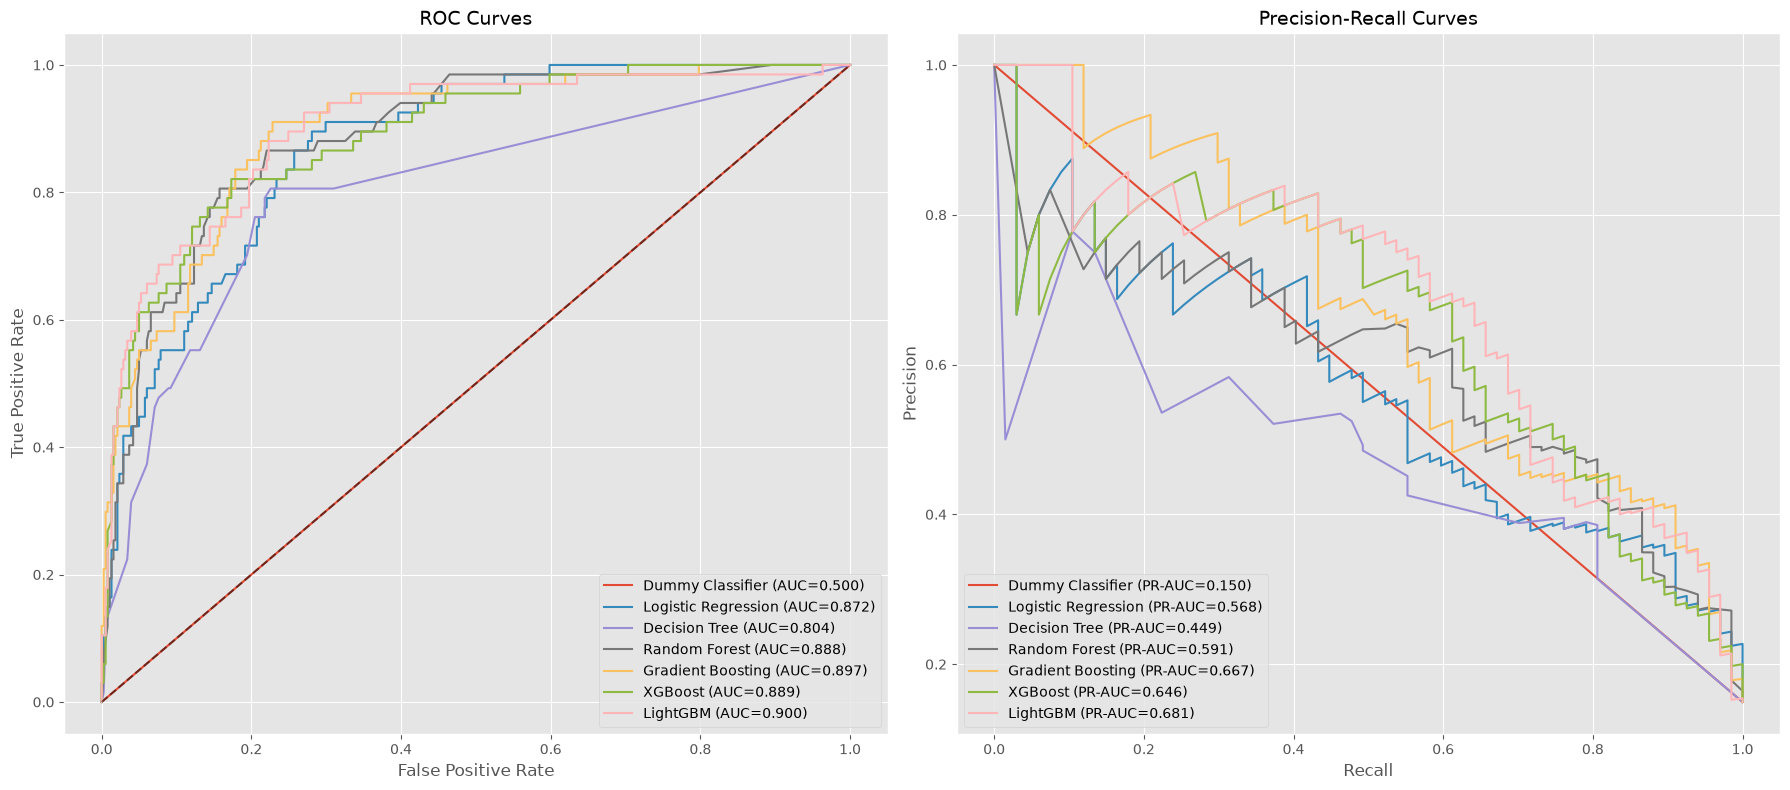

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for name, pipe in trained_pipelines.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')
    
    # PR
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    axes[1].plot(rec, prec, label=f'{name} (PR-AUC={pr_auc:.3f})')

axes[0].plot([0,1], [0,1], 'k--', alpha=0.5)
axes[0].set_title('ROC Curves', fontsize=14)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

axes[1].set_title('Precision-Recall Curves', fontsize=14)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.savefig('../outputs/crisp_dm_modeling/figures/evaluation_curves.png')
plt.show()


## 5. Final Model Selection & Confusion Matrix\nWe select the model that yielded the absolute highest **F1-Score**, as this metric balances Precision (budget efficiency) and Recall (capture rate) perfectly for our marketing campaign.

SELECTED BEST MODEL: LightGBM


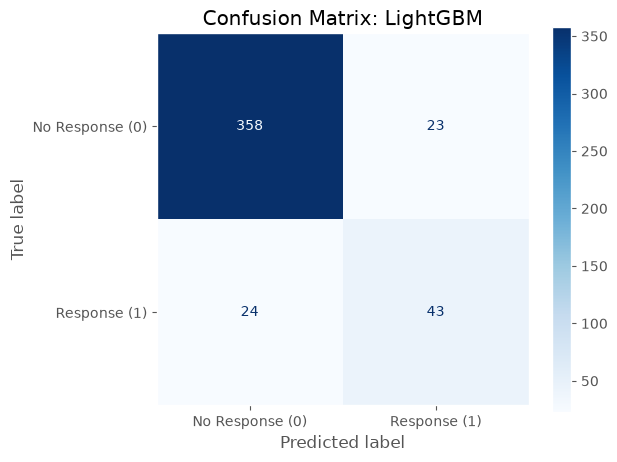

In [5]:
best_model_name = comparison_df.iloc[0]['Model']
best_pipe = trained_pipelines[best_model_name]

print(f"SELECTED BEST MODEL: {best_model_name}")

# Save Model
joblib.dump(best_pipe, '../models/final/best_classifier_pipeline.joblib')

# Confusion Matrix for Best Model
y_pred_best = best_pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Response (0)', 'Response (1)'])
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title(f'Confusion Matrix: {best_model_name}')
plt.grid(False)
plt.savefig('../outputs/crisp_dm_modeling/figures/best_model_confusion_matrix.png')
plt.show()


### Conclusion\nThe modeling phase is fully complete. The best model has been dynamically selected, validated, and serialized to disk. As requested, we will halt the pipeline here before diving into SHAP interpretations.